## 稠密连接网络
ResNet极大地改变了如何参数化深层网络中函数的观点。 稠密连接网络（DenseNet） (Huang et al., 2017)在某种程度上是ResNet的逻辑扩展。
ResNet（左）与 DenseNet（右）在跨层连接上的主要区别：使用相加和使用连结:<br/>
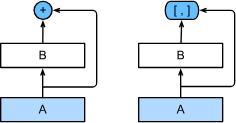<br/>
ResNet和DenseNet的关键区别在于，DenseNet输出是连接而不是如ResNet的简单相加。 DenseNet这个名字由变量之间的“稠密连接”而得来，最后一层与之前的所有层紧密相连。 稠密连接如下:<br/>
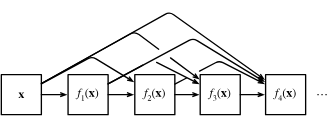
### 稠密块体
DenseNet使用了ResNet改良版的“批量规范化、激活和卷积”架构

In [24]:
import torch
from torch import nn
from d2l import torch as d2l

def conv_block(input_channels,num_channels):
    return nn.Sequential(
        nn.BatchNorm2d(input_channels),nn.ReLU(),
        nn.Conv2d(input_channels,num_channels,kernel_size=3,padding=1)
    )

一个稠密块由多个卷积块组成，每个卷积块使用相同数量的输出通道。 然而，在前向传播中，我们将每个卷积块的输入和输出在通道维上连结。

In [25]:
class DenseBlock(nn.Module):
    def __init__(self,num_convs,input_channels,num_channels):
        super(DenseBlock,self).__init__()
        layer = []
        for i in range(num_convs):
            layer.append(conv_block(num_channels * i + input_channels,num_channels))
        self.net = nn.Sequential(*layer)
    def forward(self,X):
        for blk in self.net:
            Y = blk(X)
            # 连接通道维度上每个块的输入和输出
            X = torch.cat((X,Y),dim=1)
        return X
    

在下面的例子中，我们定义一个有2个输出通道数为10的DenseBlock。 使用通道数为3的输入时，我们会得到通道数为3+2x10=23的输出。卷积块的通道数控制了输出通道数相对于输入通道数的增长，因此也被称为增长率（growth rate）。

In [26]:
blk = DenseBlock(2,3,10)
X = torch.randn(4,3,8,8)
Y = blk(X)
Y.shape

torch.Size([4, 23, 8, 8])

### 过渡层
由于每个稠密块都会带来通道数的增加，使用过多则会过于复杂化模型。 而过渡层可以用来控制模型复杂度。 它通过1x1卷积层来减小通道数，并使用步幅为2的平均汇聚层减半高和宽，从而进一步降低模型复杂度。

In [27]:
def transition_block(input_channels,num_channels):
    return nn.Sequential(
        nn.BatchNorm2d(input_channels),nn.ReLU(),
        nn.Conv2d(input_channels,num_channels,kernel_size=1),
        nn.AvgPool2d(kernel_size=2,stride=2)
    )
# 对上一个例子中稠密块的输出使用通道数为10的过渡层。 此时输出的通道数减为10，高和宽均减半。
blk = transition_block(23,10)
blk(Y).shape

torch.Size([4, 10, 4, 4])

### DenseNet模型
DenseNet首先使用同ResNet一样的单卷积层和最大汇聚层。

In [28]:
b1 = nn.Sequential(
    nn.Conv2d(1,64,kernel_size=7,stride=2,padding=3),
    nn.BatchNorm2d(64),nn.ReLU(),
    nn.MaxPool2d(kernel_size=3,stride=2,padding=1)
)

接下来，类似于ResNet使用的4个残差块，DenseNet使用的是4个稠密块。 与ResNet类似，我们可以设置每个稠密块使用多少个卷积层。 这里我们设成4，从而与 7.6节的ResNet-18保持一致。 稠密块里的卷积层通道数（即增长率）设为32，所以每个稠密块将增加128个通道。
在每个模块之间，ResNet通过步幅为2的残差块减小高和宽，DenseNet则使用过渡层来减半高和宽，并减半通道数。

In [29]:
# num_channels为当前的通道数
num_channels, growth_rate = 64, 32
num_convs_in_dense_blocks = [4, 4, 4, 4]
blks = []
for i, num_convs in enumerate(num_convs_in_dense_blocks):
    blks.append(DenseBlock(num_convs, num_channels, growth_rate))
    # 上一个稠密块的输出通道数
    num_channels += num_convs * growth_rate
    # 在稠密块之间添加一个转换层，使通道数量减半
    if i != len(num_convs_in_dense_blocks) - 1:
        blks.append(transition_block(num_channels, num_channels // 2))
        num_channels = num_channels // 2


In [33]:
net = nn.Sequential(
    b1,*blks,
    nn.BatchNorm2d(num_channels),nn.ReLU(),
    nn.AdaptiveAvgPool2d((1,1)),
    nn.Flatten(),
    nn.Linear(num_channels,10)
)

### 训练模型


loss 0.140, train acc 0.949, test acc 0.905
2833.8 examples/sec on cuda:0


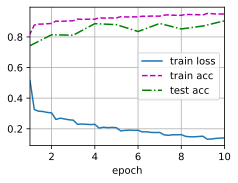

In [34]:
lr, num_epochs, batch_size = 0.1, 10, 256
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size, resize=96)
d2l.train_ch6(net, train_iter, test_iter, num_epochs, lr, d2l.try_gpu())

### 小结
在跨层连接上，不同于ResNet中将输入与输出相加，稠密连接网络（DenseNet）在通道维上连结输入与输出。

DenseNet的主要构建模块是稠密块和过渡层。

在构建DenseNet时，我们需要通过添加过渡层来控制网络的维数，从而再次减少通道的数量。